In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def generate_handcrafted_data(n_points=5000):
    np.random.seed(42)
    time = np.arange(n_points)
    df = pd.DataFrame(index=time)

    # Generate 10 distinct features
    for i in range(10):
        # Mix of seasonality, trend, and noise
        seasonal = 10 * np.sin(2 * np.pi * time / np.random.randint(100, 500))
        trend = 0.002 * time * np.random.choice([-1, 1])
        noise = np.random.normal(0, 1.5, n_points)
        df[f'metric_{i}'] = seasonal + trend + noise

    # --- COMPLICATED ANOMALY DERIVATION ---
    # Trigger 1: System Overload (High Metric 0 AND High Metric 1)
    cond1 = (df['metric_0'] > 12) & (df['metric_1'] > 10)

    # Trigger 2: Rapid Divergence (Metric 4 drops while Metric 9 spikes)
    cond2 = (df['metric_4'] < -10) & (df['metric_9'] > 8)

    df['anomaly'] = (cond1 & cond2 ).astype(int)

    # Simulate 'Incident Duration': An anomaly lasts for a window of time
    df['anomaly'] = df['anomaly'].rolling(window=5, center=True).max().fillna(0).astype(int)

    return df

# Initialize Dataset
df = generate_handcrafted_data()

In [2]:
def print_dataset_stats(df):
    print("### Dataset Overview ###")
    print(f"Total Timestamps: {len(df)}")
    print(f"Number of Features: {len(df.columns) - 1}")

    # Check Anomaly Distribution
    anomaly_counts = df['anomaly'].value_counts(normalize=True) * 100
    print("\n### Target Distribution (Class Imbalance) ###")
    print(f"Normal State: {anomaly_counts[0]:.2f}%")
    print(f"Incident State: {anomaly_counts[1]:.2f}%")

    # Descriptive Stats
    stats = df.describe().T[['mean', 'std', 'min', 'max']]
    print("\n### Feature Statistics ###")
    print(stats)

print_dataset_stats(df)

### Dataset Overview ###
Total Timestamps: 5000
Number of Features: 10

### Target Distribution (Class Imbalance) ###
Normal State: 97.22%
Incident State: 2.78%

### Feature Statistics ###
              mean       std        min        max
metric_0  5.058050  7.721399 -12.193277  22.547642
metric_1  5.217387  7.755851 -12.404249  22.702349
metric_2 -4.991972  7.965522 -24.319278  12.837064
metric_3  5.156114  7.763708 -12.419512  23.214595
metric_4 -4.969297  7.913008 -23.761972  13.292143
metric_5 -4.996631  7.908542 -23.192894  12.770951
metric_6  5.038468  7.673361 -12.177155  23.402231
metric_7 -4.790596  7.794530 -22.618952  12.669665
metric_8 -4.951675  7.927579 -22.778154  14.123119
metric_9  5.011559  7.716484 -12.501632  22.841926
anomaly   0.027800  0.164416   0.000000   1.000000


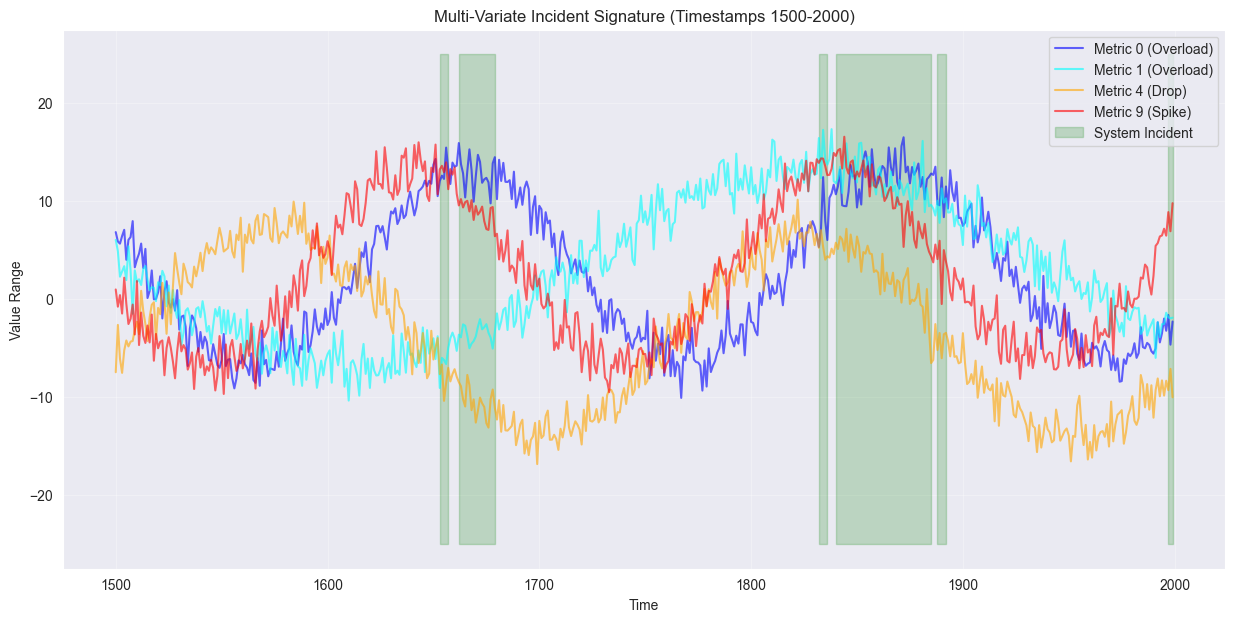

In [15]:
def plot_incident_signature(df, start=1500, end=2000):
    subset = df.iloc[start:end]
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Plot drivers for Cond 1
    ax1.plot(subset.index, subset['metric_0'], label='Metric 0 (Overload)', color='blue', alpha=0.6)
    ax1.plot(subset.index, subset['metric_1'], label='Metric 1 (Overload)', color='cyan', alpha=0.6)

    # Plot drivers for Cond 2
    ax1.plot(subset.index, subset['metric_4'], label='Metric 4 (Drop)', color='orange', alpha=0.6)
    ax1.plot(subset.index, subset['metric_9'], label='Metric 9 (Spike)', color='red', alpha=0.6)

    # Highlight the Anomaly
    ax1.fill_between(subset.index, -25, 25, where=subset['anomaly']==1,
                     color='green', alpha=0.2, label='System Incident')

    plt.title(f"Multi-Variate Incident Signature (Timestamps {start}-{end})")
    plt.xlabel("Time")
    plt.ylabel("Value Range")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_incident_signature(df)

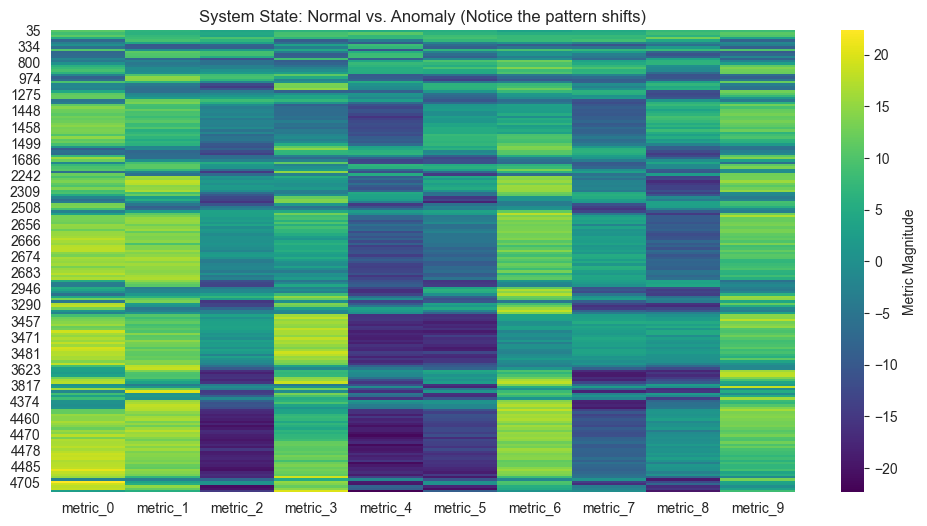

In [4]:
def plot_state_comparison(df):
    # Sample 100 normal and 100 anomaly points for clear comparison
    normal_points = df[df['anomaly'] == 0].sample(100)
    anomaly_points = df[df['anomaly'] == 1].sample(100)
    combined = pd.concat([normal_points, anomaly_points])

    plt.figure(figsize=(12, 6))
    sns.heatmap(combined.drop(columns='anomaly').sort_index(),
                cmap='viridis', cbar_kws={'label': 'Metric Magnitude'})
    plt.title("System State: Normal vs. Anomaly (Notice the pattern shifts)")
    plt.show()

plot_state_comparison(df)

In [5]:
def create_sliding_window_dataset(df, W=20, H=5, target_col='anomaly'):
    """
    Transforms time-series into a supervised learning format.
    W: Lookback window (History)
    H: Prediction horizon (Label 1 if anomaly occurs anywhere in next H steps)
    """
    feature_cols = [c for c in df.columns if 'metric' in c]
    num_features = len(feature_cols)

    X, y = [], []

    # We stop at len - W - H to ensure we have enough data for the future label
    for i in range(len(df) - W - H + 1):
        # 1. Grab the window and flatten it: (W, num_features) -> (W * num_features,)
        window = df.iloc[i : i + W][feature_cols].values.flatten()
        X.append(window)

        # 2. Look ahead H steps for the label
        # If any anomaly exists in the next H steps, label = 1 (Early Warning)
        future_window = df.iloc[i + W : i + W + H][target_col]
        y.append(1 if future_window.max() > 0 else 0)

    return np.array(X), np.array(y)

# Let's use W=20 (20 previous steps) to predict H=10 (next 10 steps)
W_size = 20
H_size = 10
X, y = create_sliding_window_dataset(df, W=W_size, H=H_size)

print(f"X Shape: {X.shape}") # Expected: (Samples, W * 10)
print(f"y Shape: {y.shape}")

X Shape: (4971, 200)
y Shape: (4971,)


In [6]:
def extract_window_stats(X_raw, W, num_metrics=10):
    """
    Optional: Instead of just raw values, we add mean/std of the window.
    This helps the model understand 'volatility' vs 'level'.
    """
    X_reshaped = X_raw.reshape(-1, W, num_metrics)

    # Calculate stats across the 'W' dimension
    means = np.mean(X_reshaped, axis=1) # (Samples, 10)
    stds = np.std(X_reshaped, axis=1)   # (Samples, 10)
    maxs = np.max(X_reshaped, axis=1)

    # Combine raw flattened data with these stats
    return np.hstack([X_raw, means, stds, maxs])

X_enriched = extract_window_stats(X, W=W_size)
print(f"Enriched Feature Count: {X_enriched.shape[1]}")

Enriched Feature Count: 230


In [7]:
# 80% Train, 20% Test (Chronological)
split_idx = int(len(X_enriched) * 0.8)

X_train, X_test = X_enriched[:split_idx], X_enriched[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Anomaly Rate in Test: {y_test.mean():.2%}")

Training samples: 3976
Testing samples: 995
Anomaly Rate in Test: 4.82%


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

# Calculate the imbalance ratio for scale_pos_weight
# Formula: sum(negative_instances) / sum(positive_instances)
imbalance_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialize XGBoost with optimized parameters for time-series anomalies
model = XGBClassifier(
    n_estimators=150,
    max_depth=5,            # Enough depth to capture the 'AND' logic of your conditions
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio,
    subsample=0.8,          # Prevent overfitting by training on subsets
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='aucpr',    # Area Under Precision-Recall is best for imbalances
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Generate Predictions
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

/Users/riyabora/PycharmProjects/MLPredictive/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:51:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98       947
    Incident       1.00      0.10      0.19        48

    accuracy                           0.96       995
   macro avg       0.98      0.55      0.58       995
weighted avg       0.96      0.96      0.94       995



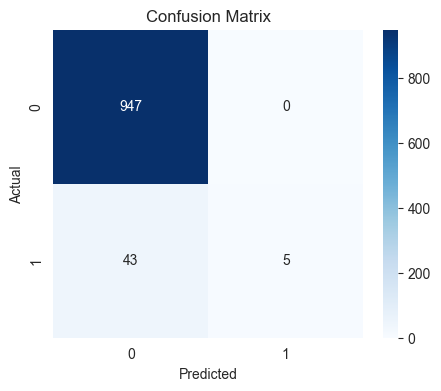

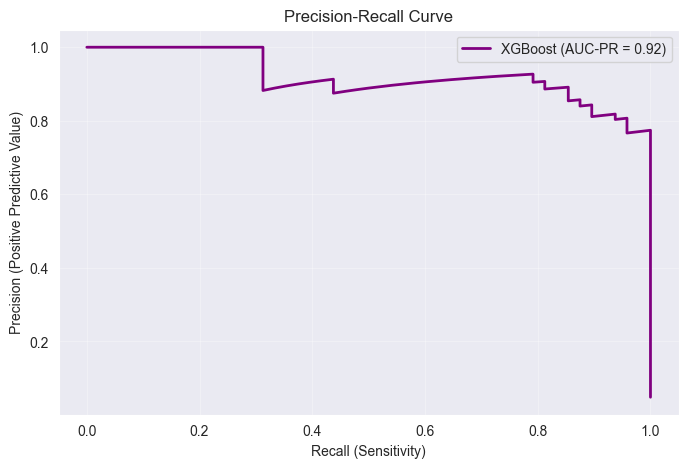

In [9]:
def evaluate_model(y_true, y_pred, y_probs):
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Incident']))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Precision-Recall Curve (The "Gold Standard" for Anomaly Detection)
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 5))
    plt.plot(recall, precision, label=f'XGBoost (AUC-PR = {pr_auc:.2f})', color='purple', lw=2)
    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision (Positive Predictive Value)')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

evaluate_model(y_test, y_pred, y_probs)

In [10]:
# Instead of y_pred = model.predict(X_test)
# We use the raw probabilities to find our 80% recall point

def predict_at_recall_target(y_probs, y_true, target_recall=0.80):
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)

    # Find the threshold that gets us closest to our target recall
    idx = np.where(recall >= target_recall)[0][-1]
    optimal_threshold = thresholds[idx]

    y_pred_new = (y_probs >= optimal_threshold).astype(int)
    return y_pred_new, optimal_threshold

y_pred_80, threshold = predict_at_recall_target(y_probs, y_test)
print(f"New Decision Threshold for 80% Recall: {threshold:.4f}")
print(classification_report(y_test, y_pred_80))

New Decision Threshold for 80% Recall: 0.2457
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       947
           1       0.91      0.81      0.86        48

    accuracy                           0.99       995
   macro avg       0.95      0.90      0.93       995
weighted avg       0.99      0.99      0.99       995



### FINAL MODEL EVALUATION (80% Recall Target) ###
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       947
           1       0.91      0.81      0.86        48

    accuracy                           0.99       995
   macro avg       0.95      0.90      0.93       995
weighted avg       0.99      0.99      0.99       995



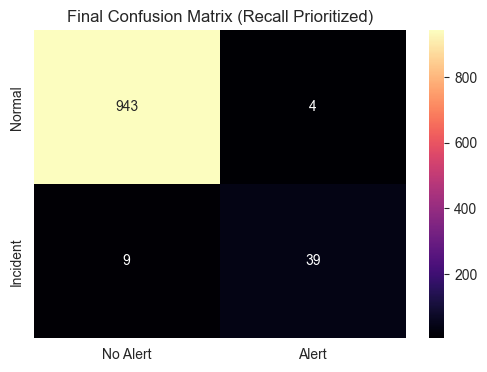

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Assuming 'threshold' was calculated to hit 80% recall
y_final_pred = (y_probs >= threshold).astype(int)

print("### FINAL MODEL EVALUATION (80% Recall Target) ###")
print(classification_report(y_test, y_final_pred))

# Confusion Matrix to show the 'False Alarm' trade-off
cm = confusion_matrix(y_test, y_final_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=['No Alert', 'Alert'], yticklabels=['Normal', 'Incident'])
plt.title("Final Confusion Matrix (Recall Prioritized)")
plt.show()

/var/folders/zl/bj746_7n1td1n16bmn9b0zn40000gn/T/ipykernel_7922/3807642237.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Metric', data=feat_df, palette='viridis')


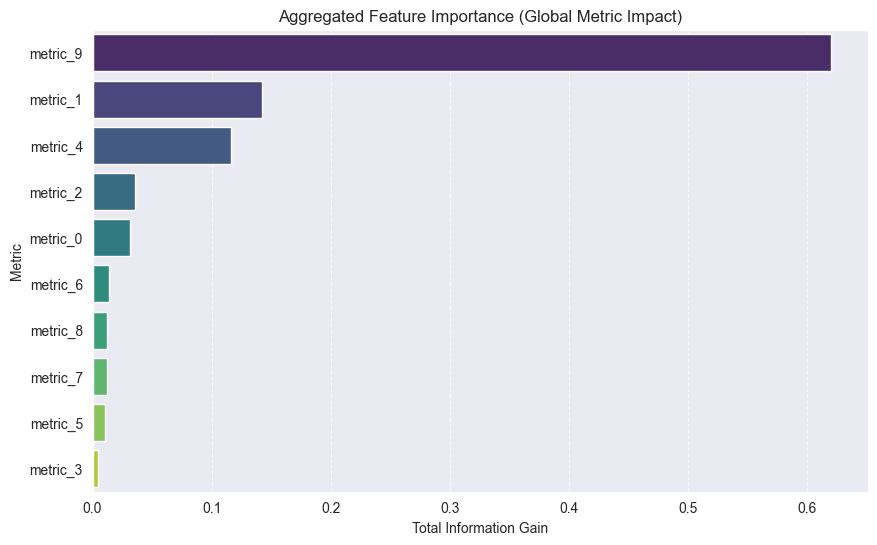

In [12]:
def plot_aggregated_importance(model, feature_names, num_metrics=10, W=20):
    # Get raw importances from XGBoost
    importances = model.feature_importances_

    # 1. Map Flattened Features back to Metrics
    # The first W * num_metrics features are raw lags
    raw_importances = importances[:W * num_metrics].reshape(W, num_metrics)
    # Sum importance across the entire window (all lags) for each metric
    metric_importance = np.sum(raw_importances, axis=0)

    # 2. Add Importance from Summary Stats (Mean, Std, Max)
    # These are the last 30 features in our X_enriched matrix
    stat_importances = importances[W * num_metrics:]
    metric_importance += stat_importances.reshape(3, num_metrics).sum(axis=0)

    # Create DataFrame for plotting
    feat_df = pd.DataFrame({
        'Metric': [f'metric_{i}' for i in range(num_metrics)],
        'Importance': metric_importance
    }).sort_values(by='Importance', ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Metric', data=feat_df, palette='viridis')
    plt.title("Aggregated Feature Importance (Global Metric Impact)")
    plt.xlabel("Total Information Gain")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# Use the feature names from your enriched dataset
plot_aggregated_importance(model, None, num_metrics=10, W=W_size)

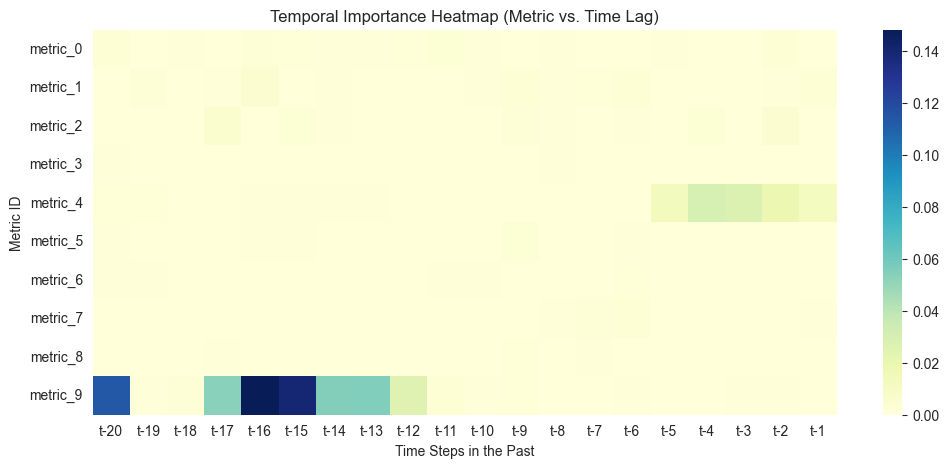

In [13]:
def plot_temporal_importance(model, W=20, num_metrics=10):
    importances = model.feature_importances_
    # Extract only the raw window features (exclude summary stats for this plot)
    raw_importances = importances[:W * num_metrics].reshape(W, num_metrics)

    plt.figure(figsize=(12, 5))
    sns.heatmap(raw_importances.T, cmap='YlGnBu',
                xticklabels=[f't-{W-i}' for i in range(W)],
                yticklabels=[f'metric_{i}' for i in range(num_metrics)])
    plt.title("Temporal Importance Heatmap (Metric vs. Time Lag)")
    plt.xlabel("Time Steps in the Past")
    plt.ylabel("Metric ID")
    plt.show()

plot_temporal_importance(model, W=W_size)